<h1>Проект по дисциплине "Основы машинного обучения"</h1>
<h2>Тема: Распознавание эмоций по лицам<br>
Выполнили студенты группы 3ИСИП-322 Сергеев И. Д., Колосова Д. С.</h2>

<h1>Введение</h1>
<h2>Распознавание эмоций по лицам на основе машинного обучения – это процесс, позволяющий автоматизировать определение эмоционального состояния человека, используя алгоритмы и модели, обученные на больших объемах данных изображений лиц. Эта задача включает в себя несколько ключевых этапов: предварительную обработку изображений, извлечение признаков и классификацию эмоций.

<br> В основе технологий распознавания эмоций лежат глубокие нейронные сети, которые способны анализировать мимику и выражения лиц с высокой точностью. Например, сверточные нейронные сети (CNN) используются для обработки изображений и выявления паттернов, соответствующих различным эмоциям, таким как счастье, грусть, гнев и страх. Эти системы находят применение в различных областях: от маркетинга и психологии до медицины и безопасности

<br>Сбор данных для обучения моделей осуществляется с использованием специализированных наборов данных, таких как FER2013, который содержит тысячи размеченных изображений лиц с различными эмоциональными состояниями. Это позволяет моделям учиться различать нюансы выражений лиц и точно классифицировать эмоции</h2>

<h1>Актуальность</h1>
<h2>Распознавание эмоций по лицам становится все более актуальным в современном мире, где технологии искусственного интеллекта и машинного обучения активно внедряются в различные сферы жизни. Эта задача важна для улучшения взаимодействия между людьми и системами, а также для повышения эффективности в таких областях, как психология, медицина, безопасность и маркетинг. В условиях растущей потребности в автоматизации анализа эмоционального состояния человека, использование глубоких нейронных сетей позволяет достигать высокой точности распознавания эмоций, что делает данный проект значимым для научных исследований и практического применения.</h2>

<h1>Цель проекта</h1>
<h2>Целью проекта является разработка системы распознавания эмоций на основе анализа лицевых выражений с использованием методов машинного обучения. Проект направлен на создание эффективной модели, способной точно классифицировать эмоциональные состояния человека, такие как гнев, отвращение, страх, радость, нейтральное, грусть, удивление, на основе изображений лиц. Это позволит не только автоматизировать процесс распознавания эмоций, но и расширить его применение в различных сферах</h2>

<h1>Этапы разработки проекта</h1>
<h2>Импорт библиотек и модулей</h2>

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

<h1>Загрузка датасета и предобработка изображений</h1>

In [27]:
train_dataset = "train"
val_dataset = "test"

transform_train = transforms.Compose([
    transforms.Resize((48, 48)),          # Изменяем размер изображений
    transforms.RandomHorizontalFlip(),    # Случайное отражение по горизонтали
    transforms.ToTensor(),                # Конвертация в тензор
    transforms.Normalize((0.5,), (0.5,))  # Нормализация
])

transform_val = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.ImageFolder(root=train_dataset, transform=transform_train)
val_dataset = datasets.ImageFolder(root=val_dataset, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f"Классы эмоций: {train_dataset.classes}")

Классы эмоций: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


<h1>Функция аугментации изображений</h1>

In [3]:
def augment_images_for_class(input_dir, class_name, augmentations=None, num_copies=5):
    if augmentations is None:
        augmentations = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),          # Случайное отражение
            transforms.RandomRotation(10),                  # Поворот до 10 градусов
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # Смена цветов
            transforms.RandomAffine(10, scale=(0.9, 1.1)),   # Сдвиг и масштабирование
        ])

    class_path = os.path.join(input_dir, class_name)

    if not os.path.isdir(class_path):
        print(f"Класс {class_name} не найден в {input_dir}.")
        return

    for image_name in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
        image_path = os.path.join(class_path, image_name)
        try:
            image = Image.open(image_path)

            for i in range(num_copies): 
                augmented_image = augmentations(image)
                augmented_image_name = f"{os.path.splitext(image_name)[0]}_aug_{i}.jpg"
                augmented_image.save(os.path.join(class_path, augmented_image_name))

        except Exception as e:
            print(f"Ошибка с изображением {image_name}: {e}")

    print(f"Аугментация для класса {class_name} завершена.")

<h1>Применение функции аугментирования на датасет</h1>

In [4]:
augment_images_for_class(
    input_dir=train_dataset.root,
    class_name="angry",           
    num_copies=2                  
)

augment_images_for_class(
    input_dir=train_dataset.root,
    class_name="disgusted",
    num_copies=17
)

augment_images_for_class(
    input_dir=train_dataset.root,
    class_name="fearful",
    num_copies=2
)

augment_images_for_class(
    input_dir=train_dataset.root,
    class_name="happy",
    num_copies=2
)

augment_images_for_class(
    input_dir=train_dataset.root,
    class_name="neutral",
    num_copies=2
)

augment_images_for_class(
    input_dir=train_dataset.root,
    class_name="surprised",
    num_copies=2
)

augment_images_for_class(
    input_dir=train_dataset.root,
    class_name="surprised",
    num_copies=2
)


rocessing angry: 100%|█████████████████████████████████████████████████████████| 19921/19921 [02:55<00:00, 113.79it/s]

Аугментация для класса angry завершена.



rocessing disgusted: 100%|████████████████████████████████████████████████████████| 7848/7848 [05:29<00:00, 23.83it/s]

Аугментация для класса disgusted завершена.



rocessing fearful: 100%|███████████████████████████████████████████████████████| 12291/12291 [01:48<00:00, 113.37it/s]

...

Аугментация для класса neutral завершена.



rocessing surprised: 100%|████████████████████████████████████████████████████████| 3171/3171 [00:35<00:00, 88.73it/s]

Аугментация для класса surprised завершена.


Processing surprised: 100%|███████████████████████████████████████████████████████| 9513/9513 [01:24<00:00, 113.10it/s]

Аугментация для класса surprised завершена.


<h1>Определение архитектуры нейронной сети</h1>

In [5]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes):
        super(EmotionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

<h1>Определение количества классов</h1>

In [6]:
num_classes = len(train_dataset.classes)
model = EmotionCNN(num_classes=num_classes)

<h1>Настройка оптимизатора и функции потерь</h1>

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

<h1>Тренировка модели</h1>

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30, Train Loss: 1.5795, Train Acc: 0.3754, Val Loss: 1.3496, Val Acc: 0.4863
Epoch 2/30, Train Loss: 1.3371, Train Acc: 0.4902, Val Loss: 1.2311, Val Acc: 0.5291
Epoch 3/30, Train Loss: 1.2440, Train Acc: 0.5293, Val Loss: 1.1579, Val Acc: 0.5578
Epoch 4/30, Train Loss: 1.1937, Train Acc: 0.5476, Val Loss: 1.1321, Val Acc: 0.5684
Epoch 5/30, Train Loss: 1.1560, Train Acc: 0.5638, Val Loss: 1.1270, Val Acc: 0.5691
Epoch 6/30, Train Loss: 1.1271, Train Acc: 0.5733, Val Loss: 1.0930, Val Acc: 0.5782
Epoch 7/30, Train Loss: 1.1010, Train Acc: 0.5823, Val Loss: 1.0837, Val Acc: 0.5876
Epoch 8/30, Train Loss: 1.0829, Train Acc: 0.5916, Val Loss: 1.0764, Val Acc: 0.5890
Epoch 9/30, Train Loss: 1.0653, Train Acc: 0.5988, Val Loss: 1.0792, Val Acc: 0.5908
Epoch 10/30, Train Loss: 1.0497, Train Acc: 0.6047, Val Loss: 1.0583, Val Acc: 0.5952
Epoch 11/30, Train Loss: 1.0400, Train Acc: 0.6070, Val Loss: 1.0674, Val Acc: 0.5982
Epoch 12/30, Train Loss: 1.0288, Train Acc: 0.6107, Val Loss: 1

<h1>Визуализация результатов обучения</h1>

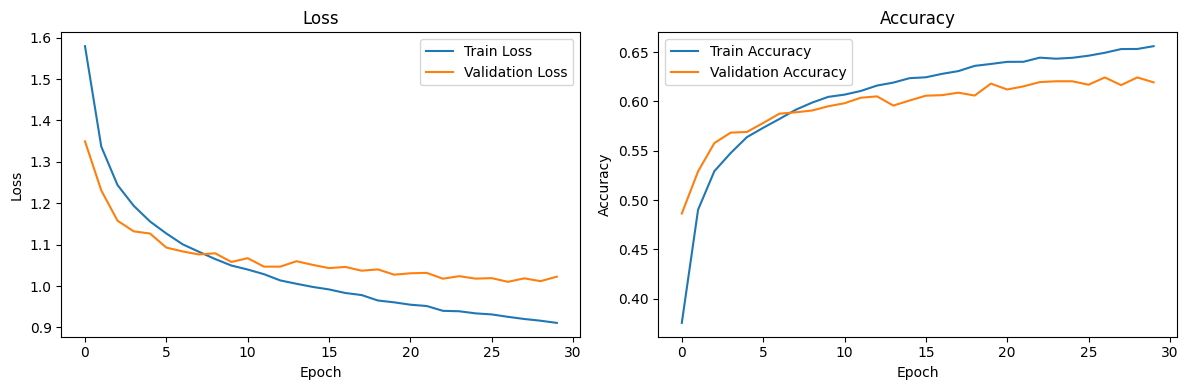

In [9]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

<h1>Анализ модели и матрица ошибок </h1>

Классификационный отчет:
              precision    recall  f1-score   support

       angry       0.50      0.59      0.54       958
   disgusted       0.64      0.68      0.66       111
     fearful       0.55      0.26      0.35      1024
       happy       0.80      0.86      0.83      1774
     neutral       0.52      0.69      0.59      1233
         sad       0.50      0.48      0.49      1247
   surprised       0.80      0.68      0.74       831

    accuracy                           0.62      7178
   macro avg       0.62      0.61      0.60      7178
weighted avg       0.62      0.62      0.61      7178



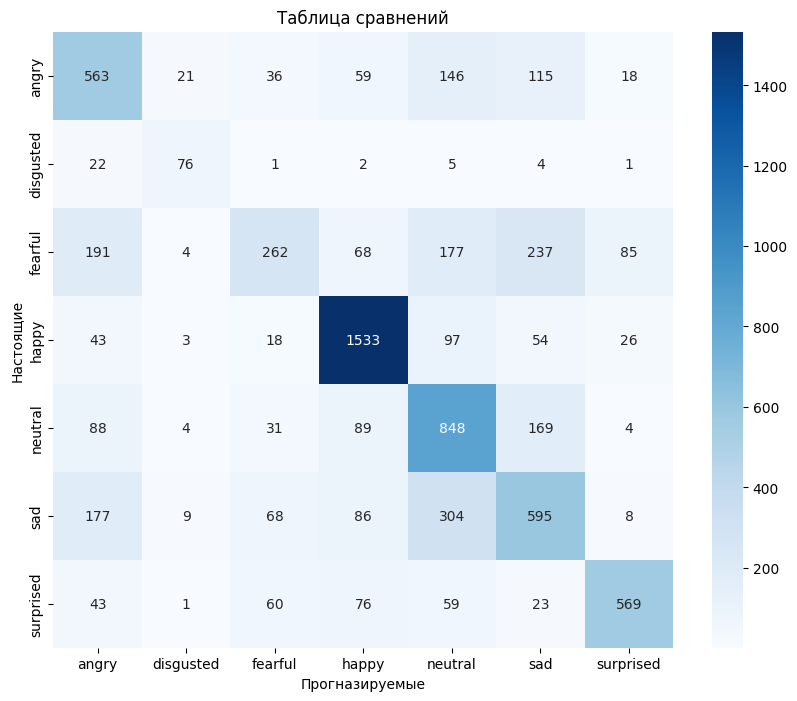

In [30]:
def evaluate_model(model, val_loader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            preds = torch.argmax(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("Классификационный отчет:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Прогнозируемые')
    plt.ylabel('Настоящие')
    plt.title('Таблица сравнений')
    plt.show()

class_names = train_dataset.classes
evaluate_model(model, val_loader, class_names)

<h1>Сохранение модели</h1>

In [11]:
torch.save(model.state_dict(), 'emotion_recognition_model.pth')

<h1>Функция предсказания эмоции</h1>

In [14]:
def predict_emotion(model, image_path, class_names):
    image = Image.open(image_path).convert('RGB') 

    transform = transforms.Compose([
        transforms.Resize((48, 48)),             # Изменяем размер до 48x48
        transforms.ToTensor(),                   # Преобразуем в тензор
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Нормализация для 3 каналов
    ])
    image_tensor = transform(image).unsqueeze(0)  # Добавляем измерение батча

    model.eval()
    with torch.no_grad():
        output = model(image_tensor) 
        predicted_class = torch.argmax(output, 1).item()

    print(f'Predicted Emotion: {class_names[predicted_class]}')

    plt.imshow(image)
    plt.title(f'Predicted Emotion: {class_names[predicted_class]}')
    plt.axis('off')
    plt.show()

<h1>Предсказание модели</h1>

Predicted Emotion: Sad


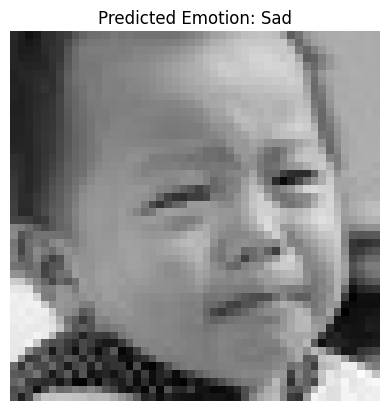

Predicted Emotion: Happy


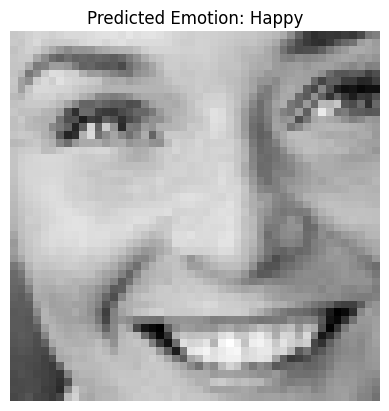

Predicted Emotion: Angry


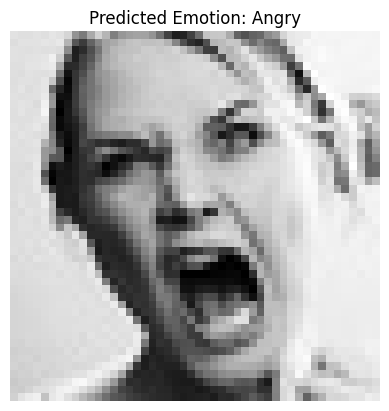

In [32]:
image_path = "TEST.jpg"
image_path2 = "TEST2.jpg"
image_path3 = "TEST3.jpg"

class_names = ["Angry", "Disgusted", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

predict_emotion(model, image_path, class_names)
predict_emotion(model, image_path2, class_names)
predict_emotion(model, image_path3, class_names)

<h1>Заключение</h1>
<h2>Вывод</h2>
<h3>В ходе проектной деятельности была создана сверточная нейросеть на PyTorch для распознавания эмоций с изображений лиц. Модель включает сверточные слои с MaxPooling и полносвязную классификацию. Для оценки добавлены матрица ошибок и классификационный отчет. На первой эпохе точность составила около 37.54%, а на последней — около 65.61%.
Валидационная точность также возросла с 48.63% до 61.94%.</h3>

<h1>Список источников:</h1>
<h3>
<ul>
    <li>https://www.kaggle.com/datasets/ananthu017/emotion-detection-fer/code - ссылка на датасет</li>
    <li>https://sky.pro/wiki/python/svertochnye-nejronnye-seti-cnn-chto-eto-i-kak-oni-rabotayut/ - информация о сверточных нейросетях</li>
</ul>
</h3>